In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df_all = pd.read_csv('PreliminaryAnalysis.csv')
min_date = pd.to_datetime('2026-02-22 17:00:00')

In [3]:
df_all['time'] = pd.to_datetime(df_all['time'])
df = df_all.loc[df_all['time'] > min_date]


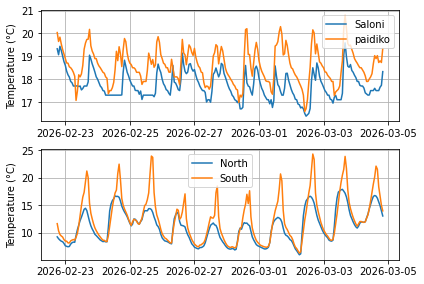

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), tight_layout=True)

ax[0].plot(df['time'], df['temp_salon_c'], label="Saloni")
ax[0].plot(df['time'], df['temp_kids_c'], label="paidiko")
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid()
ax[0].legend()

ax[1].plot(df['time'], df['temp_out_1_b_c'], label="North")
ax[1].plot(df['time'], df['temp_out_2_n_c'], label="South")
ax[1].set_ylabel("Temperature (°C)")
ax[1].grid()
ax[1].legend()

plt.show()

## Cooling Rate (<sup>o</sup>C/hour)

### Τι μετράμε

Θέλουμε για κάθε ζώνη (π.χ. Βόρειο μέσα / Νότιο μέσα) να βρούμε τον ρυθμό πτώσης στη “καθαρή” νυχτερινή περίοδο:
π.χ. 00:00–05:00 ή 01:00–06:00
αποφεύγεις ώρες με HVAC/μαγείρεμα/έντονη χρήση

### Απλή μέθοδος (robust)

Για κάθε μέρα:

φιλτράρεις τις ώρες της νύχτας

κάνεις γραμμική παλινδρόμηση T_in = a + b * t

το b είναι το cooling rate (°C/ώρα) — συνήθως αρνητικό

Το ωραίο: βγάζεις ένα rate ανά μέρα → βλέπεις σταθερότητα/μεταβλητότητα.

In [5]:
def compute_cooling_rate(df, column, start="01:00", end="06:00"):
    df = df.copy()
    df = df.set_index(['time'])
    results = []
    for day, group in df.groupby(df.index.date):
        night_time = group.between_time(start, end)
        if len(night_time) < 4:
            continue
        
        # Time in hours
        t = (night_time.index - night_time.index[0]).total_seconds() / 3600
        t = t.values.reshape(-1, 1)
        T = night_time[column].values.reshape(-1, 1)

        model = LinearRegression()
        model.fit(t, T)
        
        slope = model.coef_[0][0]
        r2 = model.score(t, T)

        results.append({
            "date": pd.Timestamp(day),
            "cooling_rate_C_per_h": slope,
            "r2": r2
        })

    return pd.DataFrame(results).set_index("date")

In [6]:
print(df.columns)

Index(['time', 'temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids',
       'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n'],
      dtype='object')


In [7]:
salon_rate = compute_cooling_rate(df, "temp_salon_c", start="01:00", end="06:00")

In [8]:
salon_rate.describe()

,cooling_rate_C_per_h,r2
count,10.000000,10.000000
mean,-0.104543,0.957694
std,0.027706,0.043567
min,-0.139429,0.871035
25%,-0.126857,0.954981
50%,-0.104714,0.976826
75%,-0.087143,0.985111
max,-0.059429,0.991823


In [9]:
paidiko_rate = compute_cooling_rate(df, "temp_kids_c", start="01:00", end="06:00")

In [10]:
paidiko_rate.describe()

,cooling_rate_C_per_h,r2
count,10.000000,10.000000
mean,-0.097543,0.967129
std,0.023881,0.022443
min,-0.137429,0.923751
25%,-0.113929,0.958838
50%,-0.089143,0.969200
75%,-0.084071,0.980916
max,-0.067429,0.996248


## Πρώτα αποτελέσματα - 1

### Cooling rate

#### Σαλόνι
mean slope = -0.1045 $^oC/h$
δηλαδή περίπου -0.10$^οC/h$
#### Παιδικό
mean slope = -0.0975 $^oC/h$
δηλαδή περίπου -0.098  $^oC/h$

Διαφορά $\approx 6\%$ (πολύ μικρή)

Αυτό σημαίνει ότι τη νύχτα η ηλιακή φόρτιση έχει φύγει και η απώλεια γίνεται κυρίως από το κέλυφος.

## Πρώτα αποτελέσματα - 2

### $R^2$

#### Σαλόνι
mean $R^2 = 0.957$

#### Παιδικό
mean $R^2 = 0.967$

Πρακτικά σημαίνει ότι $T(t) \approx a + bt$ περιγράφει πολύ καλά τη νυχτερινή συμπεριφορά. Δηλαδή:
* δεν έχει disturbances
* δεν ανοίγουν παράθυρα
* δεν έχει heating events
άρα ένα καλό dataset για modeling

## Πρώτα αποτελέσματα - 3

### Variability

#### std slope 
Βόρειο $0.027 ^oC/h$

Νότιο = $0.24^oC/h$

δηλαδή variation περίπου $\pm 25\%$

Αυτό είναι απολύτως φυσιολογικό αφού επηρεάζεται από:
* εξωτερική θερμοκρασία
* άνεμο
* cloud cover
* thermal inertia της ημέρας

## Πρώτα αποτελέσματα - 4

### Φυσική ερμηνεία

Αν η απώλεια είναι $\approx 0.1 ^oC/h$ τότε σε 10 ώρες: $\approx 1 ^oC$ δηλαδή το σπίτι κρατάει θερμότητα αρκετά καλά. Γενικά:

| Cooling rate | Interpretation |
| :---: | :-----------: |
| -0.05 | πολύ καλή μόνωση |
| -0.10 | καλή |
| -0.20 | μέτρια |
| -0.30+ | κακή |

## Πρώτα αποτελέσματα - 5

### Ενδιαφέρον

Το north vs south είναι σχεδόν ίδιο.

Αυτό σημαίνει:

η μεγάλη διαφορά θερμοκρασίας που βλέπεις μέσα στη μέρα μάλλον προέρχεται από:

☀️ solar gain

και όχι από διαφορετική απώλεια θερμότητας.

Πολύ σημαντικό insight.

### cooling rate “κανονικοποιημένο” ως προς έξω

Επειδή άλλοτε έχει 5°C έξω και άλλοτε 12°C, ο σκέτος ρυθμός πτώσης δεν είναι πλήρως συγκρίσιμος.

Ο πιο engineering δείκτης είναι να κοιτάξεις:

ΔT = T_in − T_out (για το αντίστοιχο έξω Β/Ν)
και να κάνεις regression στο ln(ΔT) (δες παρακάτω στο model).

## Thermal model πρώτης τάξης (1st order / RC)

$\frac{dT_{in}}{dt}=−k(T_{in}−T_{out})+u(t)$

Όπου:

k = 1/τ (1/ώρα) είναι το “leakiness” του χώρου (thermal loss rate - heat loss coefficient)

τ = time constant (ώρες): όσο μεγαλύτερο τ, τόσο πιο αργά αλλάζει θερμοκρασία (πιο “αδρανές”/καλύτερα μονωμένο)

u(t) = εσωτερικές πηγές (θέρμανση, άνθρωποι, ήλιος, συσκευές) — ιδανικά τη νύχτα το θεωρούμε ~0

$\frac{dT_{in}}{dt}=−k(T_{in}−T_{out})$

Νυχτερινό fit (ιδανικό για αρχή)

Σε νυχτερινά παράθυρα χωρίς θέρμανση:

$Tin(t)−Tout(t)≈(Tin(0)−Tout(0))e^{−kt}$

Άρα:

$ln⁡(ΔT(t))=ln⁡(ΔT(0))−kt$

Οπότε:

Φτιάχνεις ΔT = T_in − T_out

Κρατάς μόνο σημεία που ΔT > 0 (ώστε να παίρνεις log)

Κάνεις linear regression: ln(ΔT) = c + (-k)*t

Παίρνεις k και μετά τ = 1/k

Γιατί αυτό είναι καλύτερο από “σκέτο cooling rate”

Γιατί το cooling rate σε °C/h εξαρτάται από το “πόσο ζεστό είσαι” σε σχέση με έξω. Το k και το τ είναι πιο “ιδιότητα” του χώρου.

In [11]:
def compute_normalized_cooling_rate(df, column_in, column_out,  start="01:00", end="06:00"):
    df = df.copy()
    df = df.set_index(['time'])
    results = []
    
    for day, group in df.groupby(df.index.date):
        night_time = group.between_time(start, end).dropna(subset=[column_in, column_out])
        if len(night_time) < 4:
            continue
        
        T_in = night_time[column_in].to_numpy(dtype=float)
        T_out = night_time[column_out].to_numpy(dtype=float)
        
        # χρόνος σε ώρες από την αρχή του παραθύρου
        t_hours = (night_time.index - night_time.index[0]).total_seconds() / 3600.0
        t_hours = np.asarray(t_hours, dtype=float)
        
        # dT/dt σε °C/h
        dT_dt = np.gradient(T_in, t_hours)

        # ΔΤ μέσα-έξω
        deltaT = T_in - T_out
        
        # Κόβουμε σημεία όπου ΔΤ είναι πολύ μικρό ή αρνητικό
        mask = deltaT > 0.5

        if mask.sum() < 3:
            continue
        
        k_values = -dT_dt[mask] / deltaT[mask]
        k = np.mean(k_values)
        
        results.append({
            "date": pd.Timestamp(day),
            "k_1_per_h": k,
            "tau_h": 1.0 / k if k > 0 else np.nan,
            "mean_deltaT": np.mean(deltaT[mask]),
            "mean_dTdt": np.mean(dT_dt[mask]),
            "n_points": int(mask.sum())
        })

    return pd.DataFrame(results).set_index("date")

In [12]:
north_k = compute_normalized_cooling_rate(
    df,
    column_in="temp_salon_c",
    column_out="temp_out_1_b_c",
    start="01:00",
    end="06:00"
)
north_k.describe()

,k_1_per_h,tau_h,mean_deltaT,mean_dTdt,n_points
count,10.000000,10.000000,10.000000,10.000000,10.0
mean,0.011497,88.939550,9.000833,-0.104833,6.0
std,0.001764,14.275376,1.765984,0.031671,0.0
min,0.009022,72.606731,5.695000,-0.141667,6.0
25%,0.009991,76.900466,8.525833,-0.131667,6.0
50%,0.011664,85.914885,9.655000,-0.108750,6.0
75%,0.013004,100.269337,10.245833,-0.080625,6.0
max,0.013773,110.840398,10.578333,-0.055833,6.0


In [13]:
south_k = compute_normalized_cooling_rate(
    df,
    column_in="temp_kids_c",
    column_out="temp_out_2_n_c",
    start="01:00",
    end="06:00"
)
south_k.describe()

,k_1_per_h,tau_h,mean_deltaT,mean_dTdt,n_points
count,10.000000,10.000000,10.000000,10.000000,10.0
mean,0.010273,100.496416,9.440667,-0.097083,6.0
std,0.001855,19.599026,1.617870,0.024740,0.0
min,0.007373,80.568515,6.486667,-0.136667,6.0
25%,0.009017,84.116284,9.056667,-0.118750,6.0
50%,0.010457,95.636131,9.927500,-0.089583,6.0
75%,0.011890,110.911787,10.659167,-0.080000,6.0
max,0.012412,135.627675,10.876667,-0.068333,6.0


## Ερμηνεία των αποτελεσμάτων - 1

#### Βόρειο δωμάτιο (σαλόνι)
Mean: 
- k = 0.01150 1/h
- τ = 88.9 h
- ΔT ≈ 9°C
- dT/dt ≈ -0.104 °C/h

#### Νότιο δωμάτιο (παιδικό)
Mean: 
- k = 0.01027 1/h
- τ = 100.5 h
- ΔT ≈ 9.4°C
- dT/dt ≈ -0.097 °C/h


## Ερμηνεία των αποτελεσμάτων - 2
### Σύγκριση προσανατολισμών

| Δωμάτιο | k (1/h) | τ (h) |
| :---: | :-----------: | :-----------: |
| Βόρειο | 0.0115 | 88.9 |
| Νότιο | 0.0103 | 100.5 |

#### Interpretation

Το νότιο δωμάτιο έχει λίγο μεγαλύτερο τ.

Δηλαδή:
- χάνει θερμότητα πιο αργά
- έχει λίγο μεγαλύτερη θερμική αδράνεια

Πολύ λογικό γιατί:
- πιθανό solar gain
- πιθανώς διαφορετικός τοίχος / μπαλκονόπορτα
- πιθανώς διαφορετική θερμική μάζα

Αλλά η διαφορά είναι μικρή (**~12%**), που σημαίνει:

➡️ το κέλυφος του σπιτιού είναι σχετικά ομοιογενές.

## Ερμηνεία των αποτελεσμάτων - 3
#### Τι σημαίνει τ ≈ 90–100 ώρες

Η thermal time constant είναι:

$τ=\frac{1}{k}$

Αν:

τ ≈ 90 h

σημαίνει:

το σπίτι χρειάζεται περίπου 90 ώρες για να πέσει στο 37% της αρχικής διαφοράς θερμοκρασίας.

Πρακτικά:

| time | remaining ΔT |
| :--------: | :--------: |
| 1τ | 37% |
| 2τ | 13% |
| 3τ |	5% |

Άρα το σπίτι έχει σημαντική θερμική αδράνεια.

Αυτό είναι καλό.

## Ερμηνεία των αποτελεσμάτων - 4
### Έλεγχος consistency
Έχουμε:

ΔT ≈ 9°C <br>
k ≈ 0.011

Το μοντέλο λέει:

$\frac{dT}{dt} = −kΔT$

οπότε:

dT/dt≈−0.011×9
≈−0.099°C/h

που είναι ακριβώς αυτό που μετρούσες πριν (~-0.10).

Δηλαδή:

✅ τα δεδομένα είναι φυσικά συνεπή.

## Ερμηνεία των αποτελεσμάτων - 5
### Variability
Std(k):

North $\rightarrow 0.00176$

South $\rightarrow 0.00185$


δηλαδή περίπου:

±15%

Αυτό είναι απολύτως φυσιολογικό γιατί επηρεάζουν:
- άνεμος
- εξωτερική υγρασία
- ακτινοβολία από ουρανό
- θερμική μάζα της ημέρας

## Regression Method
### Γιατί η regressiom method είναι καλύτερη

Η μέθοδος που χρησιμοποιήσαμε είναι η:

$k_i = -\frac{dT/dt}{\Delta T}$

και μετά:

$k = mean(k_i)$

To $dT/dt$ έχει θόρυβο γιατί:
- gradient
- αισθητήρας 
- sampling
και μετά διαιρούμε με ΔΤ που επίσης λεχει θόρυβο.

Άρα το ratio μπορεί να γίνει unstable.

### Τι κάνει η regression
H regression λύνει:

$dT/dt = -k \Delta T$

δηλαδή κάνει fit:

$ y = dT/dt \\
x = \Delta T$

και βρίσκει slope.

Αυτό είναι καλύτερο γιατί:
* χρησιμοποιεί όλα τα δεδομένα μαζί
* μειώνει το noise
* υπολογίζει $R^2$ για quality check
* είναι η μέθοδος που χρησιμοποιείται σε building physics papers.

In [14]:
def normalized_cooling_rate_regression(df, column_in, column_out,  start="01:00", end="06:00"):
    df = df.copy()
    df = df.set_index(['time'])
    results = []
    
    for day, group in df.groupby(df.index.date):
        night_time = group.between_time(start, end).dropna(subset=[column_in, column_out])
        if len(night_time) < 4:
            continue
        
        T_in = night_time[column_in].to_numpy(dtype=float)
        T_out = night_time[column_out].to_numpy(dtype=float)
        
        # χρόνος σε ώρες από την αρχή του παραθύρου
        t_hours = (night_time.index - night_time.index[0]).total_seconds() / 3600.0
        t_hours = np.asarray(t_hours, dtype=float)
        
        # dT/dt σε °C/h
        dT_dt = np.gradient(T_in, t_hours)

        # ΔΤ μέσα-έξω
        deltaT = T_in - T_out
        
        # Κόβουμε σημεία όπου ΔΤ είναι πολύ μικρό ή αρνητικό
        mask = deltaT > 0.5

        if mask.sum() < 3:
            continue
          
        model = LinearRegression(fit_intercept=False)
        model.fit(deltaT.reshape(-1, 1), dT_dt)

        slope = model.coef_
        k = -slope
        
        results.append({
            "date": pd.Timestamp(day),
            "k_1_per_h": k,
            "tau_h": 1.0 / k if k > 0 else np.nan,
            "mean_deltaT": np.mean(deltaT[mask]),
            "mean_dTdt": np.mean(dT_dt[mask]),
            "n_points": int(mask.sum())
        })

    return pd.DataFrame(results).set_index("date")

In [15]:
north_k = compute_normalized_cooling_rate(
    df,
    column_in="temp_salon_c",
    column_out="temp_out_1_b_c",
    start="01:00",
    end="06:00"
)
north_k.describe()

,k_1_per_h,tau_h,mean_deltaT,mean_dTdt,n_points
count,10.000000,10.000000,10.000000,10.000000,10.0
mean,0.011497,88.939550,9.000833,-0.104833,6.0
std,0.001764,14.275376,1.765984,0.031671,0.0
min,0.009022,72.606731,5.695000,-0.141667,6.0
25%,0.009991,76.900466,8.525833,-0.131667,6.0
50%,0.011664,85.914885,9.655000,-0.108750,6.0
75%,0.013004,100.269337,10.245833,-0.080625,6.0
max,0.013773,110.840398,10.578333,-0.055833,6.0


In [16]:
south_k = compute_normalized_cooling_rate(
    df,
    column_in="temp_kids_c",
    column_out="temp_out_2_n_c",
    start="01:00",
    end="06:00"
)
south_k.describe()

,k_1_per_h,tau_h,mean_deltaT,mean_dTdt,n_points
count,10.000000,10.000000,10.000000,10.000000,10.0
mean,0.010273,100.496416,9.440667,-0.097083,6.0
std,0.001855,19.599026,1.617870,0.024740,0.0
min,0.007373,80.568515,6.486667,-0.136667,6.0
25%,0.009017,84.116284,9.056667,-0.118750,6.0
50%,0.010457,95.636131,9.927500,-0.089583,6.0
75%,0.011890,110.911787,10.659167,-0.080000,6.0
max,0.012412,135.627675,10.876667,-0.068333,6.0


# Going Deep (for good!)

## U-value 
Tο U-value είναι  ιδιότητα ενός δομικού στοιχείου.

$U = \frac{W}{m^2K}$

Δηλαδή πόσα Watt περνάνε ανά τετραγωνικό μέτρο για κάθε βαθμό διαφοράς θερμοκρασίας.<br>Παραδείγματα:

| Στοιχείο | U |
| :--------: | :-------- |
| παλιός τοίχος    | $1.5 \frac{W}{m^2K}$     |
| διπλό τζάμι      | $2.7 \frac{W}{m^2K}$     |
| μονωμένος τοίχος | $0.4 \frac{W}{m^2K}$     |
| passive house    | $0.1-0.2 \frac{W}{m^2K}$ |


To U αφορά ένα δομικό στοιχείο.

## UΑ-value 
Το UA αφορά όλο το κτίριο.

$UA = \sum{U_iA_i}$

όπου:
* $U_i = U$ value κάθε στοιχείου
* $Α_ι = $ επιφάνεια

Δηλαδή: **Πόσα Watt χάνει το σπίτι για κάθε βαθμό διαφοράς μέσα-έξω.**
<br>Παράδειγμα:
<br>$UA = 150 W/K$
Αν: <br> $\Delta T = 10^oC$
τότε: <br> heat loss $ = 150 * 10 = 1500W $

## Bring it all together
#### Πώς συνδέονται U-UA-k
Το μοντέλο που χρησιμοποιήσαμε ήταν:<br>
$\frac{dT}{dt} = -k (T_{in} - T_{Tout})$

αλλά το πραγματικό energy balance είναι:<br>
$C\frac{dT}{dt} = -UA (T_{in} - T_{Tout})$

όπου: **C = thermal capacity του σπιτιού ([J/K])**

άρα διαιρώντας με C έχουμε:

$\frac{dT}{dt} = -\frac{UA}{C}(T_{in} - T_{Tout})$<br>

οπότε τελικά: <br><br>$k = \frac{UA}{C}$


### Εκτίμηση thermal capacity
Η θερμική μάζα ενός σπιτιού είναι περίπου:


| στοιχείο | J/m^2^K |
| :--------: | :--------: |
| light building | 80k |
| medium building | 120k |
| heany building |	200k |

Για ένα σπίτι περίπου $100 m^2$, μπορούμε να θεωρήσουμε: <br>
thermal mass $ = 120000 J/m^2K$ και τότε:

$C \approx 1.2 \times 10^7 J/K$

### Στην περίπτωση μας
Mean k (north-south) <br> $k \approx 0.010885 1/h $ <br>
σε seconds: $k = 0.010558 / 3600 \approx 3.0236 \times 10^{-6} s^{-1}$

$UA = k \times C$ <br> $UA = 3.026 \times 10^{-6} \times 1.2 \times 10^{7}$<br> $UA = 36.312 W/K $


#### Φυσική ερμηνεία του UA

Αν έξω είναι $0^oC$ και μέσα $20^oC$, άρα $\Delta T = 20$ τότε: <br>
heat loss: $Q = UAΔΤ$<br>
$Q = 36.312\times 20$<br>
$Q = 726.24 W$
Δηλαδή το σπίτι χάνει περίπου 0.72kW σε μια τέτοια συνθήκη (λογικό για διαμέρισμα).